# Cluster Analysis and Characterization

In [60]:
# Remember: library imports are ALWAYS at the top of the script, no exceptions!
import sqlite3
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.impute import KNNImputer
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OneHotEncoder
from math import ceil

from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import KMeans

from collections import Counter
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN, estimate_bandwidth

from sklearn.base import clone
from sklearn.metrics import pairwise_distances

## New imports
from sklearn.manifold import TSNE
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.model_selection import train_test_split
import graphviz

sns.set()

In [61]:
## Un-comment these if you want to use ydata_profiling

# !pip install -U ydata-profiling
# from ydata_profiling import ProfileReport


## Context
The data we will be using through the pratical classes comes from a small relational database whose schema can be seen below:
![Schema](https://raw.githubusercontent.com/fpontejos/DMDM_2223/main/figures/schema.png "Relation database schema")

## Reading the Data

In [62]:
## Allow Colab to see Google Drive files

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
## Load csv file into a dataframe
## Paste the path here
data_path = "/content/drive/MyDrive/Colab Data/datamining.csv"

df = pd.read_csv(data_path)

In [64]:
## Load csv file into a dataframe
## Alternative location of the csv file

## data_path = "https://raw.githubusercontent.com/fpontejos/DM1_2324/main/data/datamining.csv"

## df = pd.read_csv(data_path)

### Make a copy of your original dataset

why?

In [65]:
df_original = df.copy()

### Metadata
- *id* - The unique identifier of the customer
- *age* - The year of birht of the customer
- *income* - The income of the customer
- *frq* - Frequency: number of purchases made by the customer
- *rcn* - Recency: number of days since last customer purchase
- *mnt* - Monetary: amount of € spent by the customer in purchases
- *clothes* - Number of clothes items purchased by the customer
- *kitchen* - Number of kitchen items purchased by the customer
- *small_appliances* - Number of small_appliances items purchased by the customer
- *toys* - Number of toys items purchased by the customer
- *house_keeping* - Number of house_keeping items purchased by the customer
- *dependents* - Binary. Whether or not the customer has dependents
- *per_net_purchase* - Percentage of purchases made online
- *education* - Education level of the customer
- *status* - Marital status of the customer
- *gender* - Gender of the customer
- *description* - Last customer's recommendation description

## Preprocess the Data

Remember what we did in the previous session

In [66]:
# Sometimes it is not obvious that a value is missing
# For example if the value is an empty string

# replace "" by nans
df.replace("", np.nan, inplace=True)

In [67]:
# Define metric and non-metric features. Why?
non_metric_features = ["education", "status", "gender", "dependents", "description"]

## This is saying that the metric features are all the other features that are not non-metric
## Need to be careful in case not all columns are to be used as features

# metric_features = df.columns.drop(non_metric_features).to_list()

## Or you can also specify manually
metric_features = ['age',
 'income',
 'frq',
 'rcn',
 'mnt',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase']

### Fill missing values (Data imputation)

How can we fill missing values?


#### Using measures of central tendency

In [68]:
# Creating a copy to apply central tendency measures imputation
df_central = df.copy()

In [69]:
# count of missing values
df_central.isna().sum()

,0
Unnamed: 0,0
age,0
income,46
frq,0
rcn,0
mnt,0
clothes,0
kitchen,0
small_appliances,0
toys,0


In [70]:
medians = df_central[metric_features].median()
medians

,0
age,1966.0
income,70030.5
frq,17.0
rcn,53.0
mnt,383.0
clothes,51.0
kitchen,4.0
small_appliances,28.0
toys,4.0
house_keeping,4.0


In [71]:
modes = df_central[non_metric_features].mode().loc[0]
modes

,0
education,Graduation
status,Married
gender,M
dependents,1.0
description,OK nice!


In [72]:
## Fill NaNs using medians and modes

df_central.fillna(medians, inplace=True)
df_central.fillna(modes, inplace=True)

In [73]:
df_central.isna().sum()  # checking how many NaNs we still have

,0
Unnamed: 0,0
age,0
income,0
frq,0
rcn,0
mnt,0
clothes,0
kitchen,0
small_appliances,0
toys,0


In [74]:
df = df_central.copy()

### Outlier removal

In [75]:
def remove_outliers(df, filters):

  df_2 = df[filters]
  print('Percentage of data kept after removing outliers:', 100*(np.round(df_2.shape[0] / df.shape[0], 4)))

  return df_2



In [76]:
# This may vary from session to session, and is prone to varying interpretations.
# A simple example is provided below:

manual_filters = (
    (df['house_keeping']<=50)
    &
    (df['kitchen']<=40)
    &
    (df['toys']<=35)
    &
    (df['education']!='OldSchool')
)

df_1 = remove_outliers(df, manual_filters)

Percentage of data kept after removing outliers: 97.99


In [77]:
# Get the manual filtering version
df = df_1.copy()

In [78]:
# How can we avoid having as many extreme values in 'rcn'?
print((df['rcn']>100).value_counts())

rcn_t = df['rcn'].copy()
rcn_t.loc[rcn_t>100] = 100

df['rcn'] = rcn_t

rcn
False    8437
True      380
Name: count, dtype: int64


#### What about non-metric features?

In [79]:
# Let's also remove status=Whatever
df.loc[df['status'] == 'Whatever', 'status'] = df['status'].mode()[0]


### Feature Engineering and Feature Selection

In [80]:
df['birth_year'] = df['age']
df['age'] = datetime.now().year - df['birth_year']

df['spent_online'] = (df['per_net_purchase'] / 100) * df['mnt']

#### Redundancy


In [81]:
# Select variables according to their correlations
df.drop(columns=['birth_year', 'age', 'mnt'], inplace=True)

In [82]:
# Updating metric_features
metric_features.append("spent_online")
metric_features.remove("mnt")
metric_features.remove("age")

In [83]:
metric_features

['income',
 'frq',
 'rcn',
 'clothes',
 'kitchen',
 'small_appliances',
 'toys',
 'house_keeping',
 'per_net_purchase',
 'spent_online']

#### Relevancy
Selecting variables based on the relevancy of each one to the task. Example: remove uncorrelated variables with the target, stepwise regression, use variables for product clustering, use variables for socio-demographic clustering, ...

Variables that aren't correlated with any other variable are often also not relevant. In this case we will not focus on this a lot since we don't have a defined task yet.

### Data Normalization

#### Standard Scaling

In [84]:
df_standard = df.copy()

In [85]:
scaler = StandardScaler()
scaled_feat = scaler.fit_transform(df_standard[metric_features])
df_standard[metric_features] = scaled_feat


In [86]:
df = df_standard.copy()

### One-hot encoding

In [87]:
df_ohc = df.copy()

In [88]:
def get_ohc_df(df, feats):
  # Use OneHotEncoder to encode the categorical features.
  # Get feature names and create a DataFrame
  # with the one-hot encoded categorical features (pass feature names)

  ohc = OneHotEncoder(sparse_output=False, drop="first")
  ohc_feat = ohc.fit_transform(df[feats])
  ohc_feat_names = ohc.get_feature_names_out()
  ohc_df = pd.DataFrame(ohc_feat, index=df.index, columns=ohc_feat_names)

  # Reassigning df to contain ohc variables
  df_ohc = pd.concat([df, ohc_df], axis=1)

  ## Return the df with the one-hot encoded features
  ## Also return the OneHotEncoder model (ohc)
  return df_ohc, ohc

df_ohc, ohc = get_ohc_df(df, non_metric_features)


In [89]:
oh_features = ohc.get_feature_names_out().tolist()
oh_features

['education_2nd Cycle',
 'education_Graduation',
 'education_Master',
 'education_PhD',
 'status_Married',
 'status_Single',
 'status_Together',
 'status_Widow',
 'gender_M',
 'dependents_1.0',
 'description_Kind of OK',
 'description_Meh...',
 'description_OK nice!',
 'description_Take my money!!']

In [90]:
df_ohc.columns

Index(['Unnamed: 0', 'income', 'frq', 'rcn', 'clothes', 'kitchen',
       'small_appliances', 'toys', 'house_keeping', 'dependents',
       'per_net_purchase', 'gender', 'education', 'status', 'description',
       'spent_online', 'education_2nd Cycle', 'education_Graduation',
       'education_Master', 'education_PhD', 'status_Married', 'status_Single',
       'status_Together', 'status_Widow', 'gender_M', 'dependents_1.0',
       'description_Kind of OK', 'description_Meh...', 'description_OK nice!',
       'description_Take my money!!'],
      dtype='object')

In [91]:
df = df_ohc.copy()

## Remove noise rows with DBSCAN


In [92]:
def split_noise_rows(df, feats, dbs_model):
  ## Splits the dataframe into noise and non-noise
  dbscan_labels = dbs_model.fit_predict(df[feats])

  df_concat = pd.concat([df,
                            pd.Series(dbscan_labels,
                                      name='dbscan_labels',
                                      index=df.index)], axis=1)

  df_noise = df_concat[df_concat['dbscan_labels']==-1].copy()
  df_nonoise = df_concat[df_concat['dbscan_labels']==0].copy()


  return df_noise, df_nonoise, df_concat

In [93]:
## Refer to previous notebook for how to tune DBSCAN
## Based on the hyperparameters we found

dbscan = DBSCAN(eps=1.9, min_samples=20, n_jobs=4)

df_noise, df_nonoise, df_combined_noise = split_noise_rows(df, metric_features, dbscan)

In [94]:
## Rename df_nonoise dataframe to df for simplicity
## Remember the df_combined_noise dataframe has both noise and non noise rows

print(df_combined_noise.shape)
print(df_nonoise.shape)
print(df_noise.shape)

df = df_nonoise.copy()



(8817, 31)
(8715, 31)
(102, 31)


## Clustering by Perspectives

In [95]:
## Split variables into perspectives
## This is an example; requires critical thinking and some domain knowledge

demographic_features = [
    'income',
    'frq',
    'per_net_purchase',
    'spent_online'
]

preference_features = [
    'clothes',
    'kitchen',
    'small_appliances',
    'toys',
    'house_keeping',
]

df_dem = df[demographic_features].copy()
df_prf = df[preference_features].copy()

### Apply clustering by perspectives

In [96]:
perspective_1 = 'pref_labels'
perspective_2 = 'demog_labels'

In [97]:
kmeans_pref = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=20,
    random_state=42
)
pref_labels = kmeans_pref.fit_predict(df_prf)

df['pref_labels'] = pref_labels


In [98]:
# Applying the right clustering (algorithm and number of clusters) for each perspective

kmeans_dem = KMeans(
    n_clusters=4,
    init='k-means++',
    n_init=20,
    random_state=42
)
demog_labels = kmeans_dem.fit_predict(df_dem)

df['demog_labels'] = demog_labels

In [99]:
# Count label frequencies (contigency table)

def make_contingency_table(df, label1, label2):
  df_ = df.groupby([label1, label2])\
            .size()\
            .to_frame()\
            .reset_index()\
            .pivot(index=label2, columns=label1)
  df_.columns = df_.columns.droplevel()
  return df_



In [100]:
make_contingency_table(df, perspective_1, perspective_2)


pref_labels,0,1,2
demog_labels,,,
0,640,1330,208
1,1460,1160,1013
2,1231,386,290
3,247,707,43


#### Merge using Hierarchical Clustering

In [101]:
def get_mean_bylabel(df, feats, label_name):
  # Characterizing the clusters
  return df[feats+[label_name]].groupby(label_name).mean()


In [102]:
# Centroids of the concatenated cluster labels
df_hc_centroids = df.groupby([perspective_1, perspective_2])[metric_features].mean()
df_hc_centroids

income       frq       rcn   clothes   kitchen  \
pref_labels demog_labels                                                     
0           0             0.204421 -0.108028 -0.092222 -0.244671 -0.053695   
            1            -0.937498 -0.867378  0.116664 -0.460178 -0.061302   
            2             1.226037  1.218688 -0.085587 -0.468749 -0.080271   
            3             0.935409  1.306561 -0.022407 -0.206583 -0.048124   
1           0             0.143124 -0.077764 -0.078164  1.052654 -0.575271   
            1            -0.618162 -0.882446  0.058538  0.952493 -0.604735   
            2             1.132018  1.211537  0.004280  0.736300 -0.524088   
            3             0.693508  1.131881 -0.045360  1.099258 -0.601391   
2           0             0.224697 -0.236469 -0.127944 -0.860512  1.208364   
            1            -1.328229 -0.913881  0.091910 -1.432161  1.541292   
            2             1.193349  0.955039  0.009272 -1.098035  1.199842   
            3             0.869229  1.025457 -0.091564 -0.717197  1.073944   

                          small_appliances      toys  house_keeping  \
pref_labels demog_labels                                              
0           0                     0.464931  0.012915       0.015716   
            1                     0.912527 -0.049436      -0.013709   
            2                     0.950212 -0.030460      -0.051273   
            3                     0.457913 -0.040265      -0.048750   
1           0                    -0.924548 -0.591927      -0.570078   
            1                    -0.697857 -0.608306      -0.600578   
            2                    -0.462424 -0.500623      -0.503053   
            3                    -0.958321 -0.621980      -0.603579   
2           0                    -0.261544  1.123394       0.862767   
            1                     0.021500  1.500632       1.465216   
            2                     0.248201  1.086981       0.776292   
            3                    -0.300932  0.792654       0.935015   

                          per_net_purchase  spent_online  
pref_labels demog_labels                                  
0           0                    -0.250625      0.057600  
            1                     0.828193     -0.789332  
            2                    -1.466567      0.288256  
            3                    -0.101336      2.043056  
1           0                     0.089591      0.166574  
            1                     0.653840     -0.761555  
            2                    -1.293445      0.466873  
            3                     0.205066      2.073131  
2           0                    -0.361380     -0.073773  
            1                     0.771821     -0.857517  
            2                    -1.428096      0.188365  
            3                    -0.187964      1.634177

In [103]:
## Map combinations of the two labels to their merged cluster label

def hc_merge_mapper(df, label1, label2, feats, merged_label, n_clusters=1):
  df_ = df.copy()

  # Centroids of the concatenated cluster labels
  df_centroids = df_.groupby([label1, label2])[feats].mean()

  # Re-running the Hierarchical clustering based on the correct number of clusters
  hclust = AgglomerativeClustering(
      linkage='ward',
      metric='euclidean',
      n_clusters=n_clusters
  )
  hclust_labels = hclust.fit_predict(df_centroids)
  df_centroids[merged_label] = hclust_labels

  cluster_mapper = df_centroids[merged_label].to_dict()

  # Mapping the clusters on the centroids to the observations
  df_[merged_label] = df_.apply(
      lambda row: cluster_mapper[
          (row[label1], row[label2])
      ], axis=1
  )

  return df_, df_centroids


In [104]:
df_hc_merged, df_hc_centroids = hc_merge_mapper(df, perspective_1, perspective_2, metric_features, 'hc_merged_labels', 7)


In [105]:
df_hc_merged['hc_merged_labels'].value_counts()

,count
hc_merged_labels,
5,2490
2,2100
0,1617
3,1013
6,707
4,498
1,290


In [106]:
## Get final DF
df = df_hc_merged.copy()

## Cluster Characterization

In [107]:
df.columns

Index(['Unnamed: 0', 'income', 'frq', 'rcn', 'clothes', 'kitchen',
       'small_appliances', 'toys', 'house_keeping', 'dependents',
       'per_net_purchase', 'gender', 'education', 'status', 'description',
       'spent_online', 'education_2nd Cycle', 'education_Graduation',
       'education_Master', 'education_PhD', 'status_Married', 'status_Single',
       'status_Together', 'status_Widow', 'gender_M', 'dependents_1.0',
       'description_Kind of OK', 'description_Meh...', 'description_OK nice!',
       'description_Take my money!!', 'dbscan_labels', 'pref_labels',
       'demog_labels', 'hc_merged_labels'],
      dtype='object')

### Cluster Profiles

In [108]:
def cluster_profiles(df,
                     label_columns,
                     figsize,
                     compar_titles=None,
                     colors='Set1'):
    """
    Pass df with labels columns of one or multiple clustering labels.
    Then specify this label columns to perform the cluster profile according to them.
    """
    if compar_titles == None:
        compar_titles = [""]*len(label_columns)

    fig, axes = plt.subplots(nrows=len(label_columns), ncols=2,
                             figsize=figsize, squeeze=False)
    for ax, label, titl in zip(axes, label_columns, compar_titles):

        # Filtering df
        drop_cols = [i for i in label_columns if i!=label]
        dfax = df.drop(drop_cols, axis=1)

        # Getting the cluster centroids and counts
        centroids = dfax.groupby(by=label, as_index=False).mean()
        counts = dfax.groupby(by=label, as_index=False).count().iloc[:,[0,1]]
        counts.columns = [label, "counts"]

        # Setting Data
        pd.plotting.parallel_coordinates(centroids, label,
                                         color=sns.color_palette(palette=colors), ax=ax[0])
        sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
                    palette=sns.color_palette(palette=colors))

        #Setting Layout
        handles, _ = ax[0].get_legend_handles_labels()
        cluster_labels = ["Cluster {}".format(i) for i in range(len(handles))]
        ax[0].annotate(text=titl, xy=(0.95,1.1), xycoords='axes fraction', fontsize=13, fontweight = 'heavy')
        ax[0].legend(handles, cluster_labels) # Adaptable to number of clusters
        ax[0].axhline(color="black", linestyle="--")
        ax[0].set_title("Cluster Means - {} Clusters".format(len(handles)), fontsize=13)
        ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=-20)
        ax[0].legend(loc='center left', bbox_to_anchor=(1, 0.5))
        ax[1].set_xticklabels(cluster_labels)
        ax[1].set_xlabel("")
        ax[1].set_ylabel("Absolute Frequency")
        ax[1].set_title("Cluster Sizes - {} Clusters".format(len(handles)), fontsize=13)

    plt.subplots_adjust(hspace=0.4, top=0.90)
    plt.suptitle("Cluster Simple Profilling", fontsize=23)
    plt.show()

In [109]:
# Reminder:
# perspective_1 = 'pref_labels'
# perspective_2 = 'demog_labels'

merged_label_name = 'hc_merged_labels'

In [110]:
labels_list = [perspective_2, perspective_1, merged_label_name]

<ipython-input-108-a79530ec42ab>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<ipython-input-108-a79530ec42ab>:29: UserWarning: The palette list has more values (10) than needed (7), which may not be intended.
  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<ipython-input-108-a79530ec42ab>:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(cluster_labels)


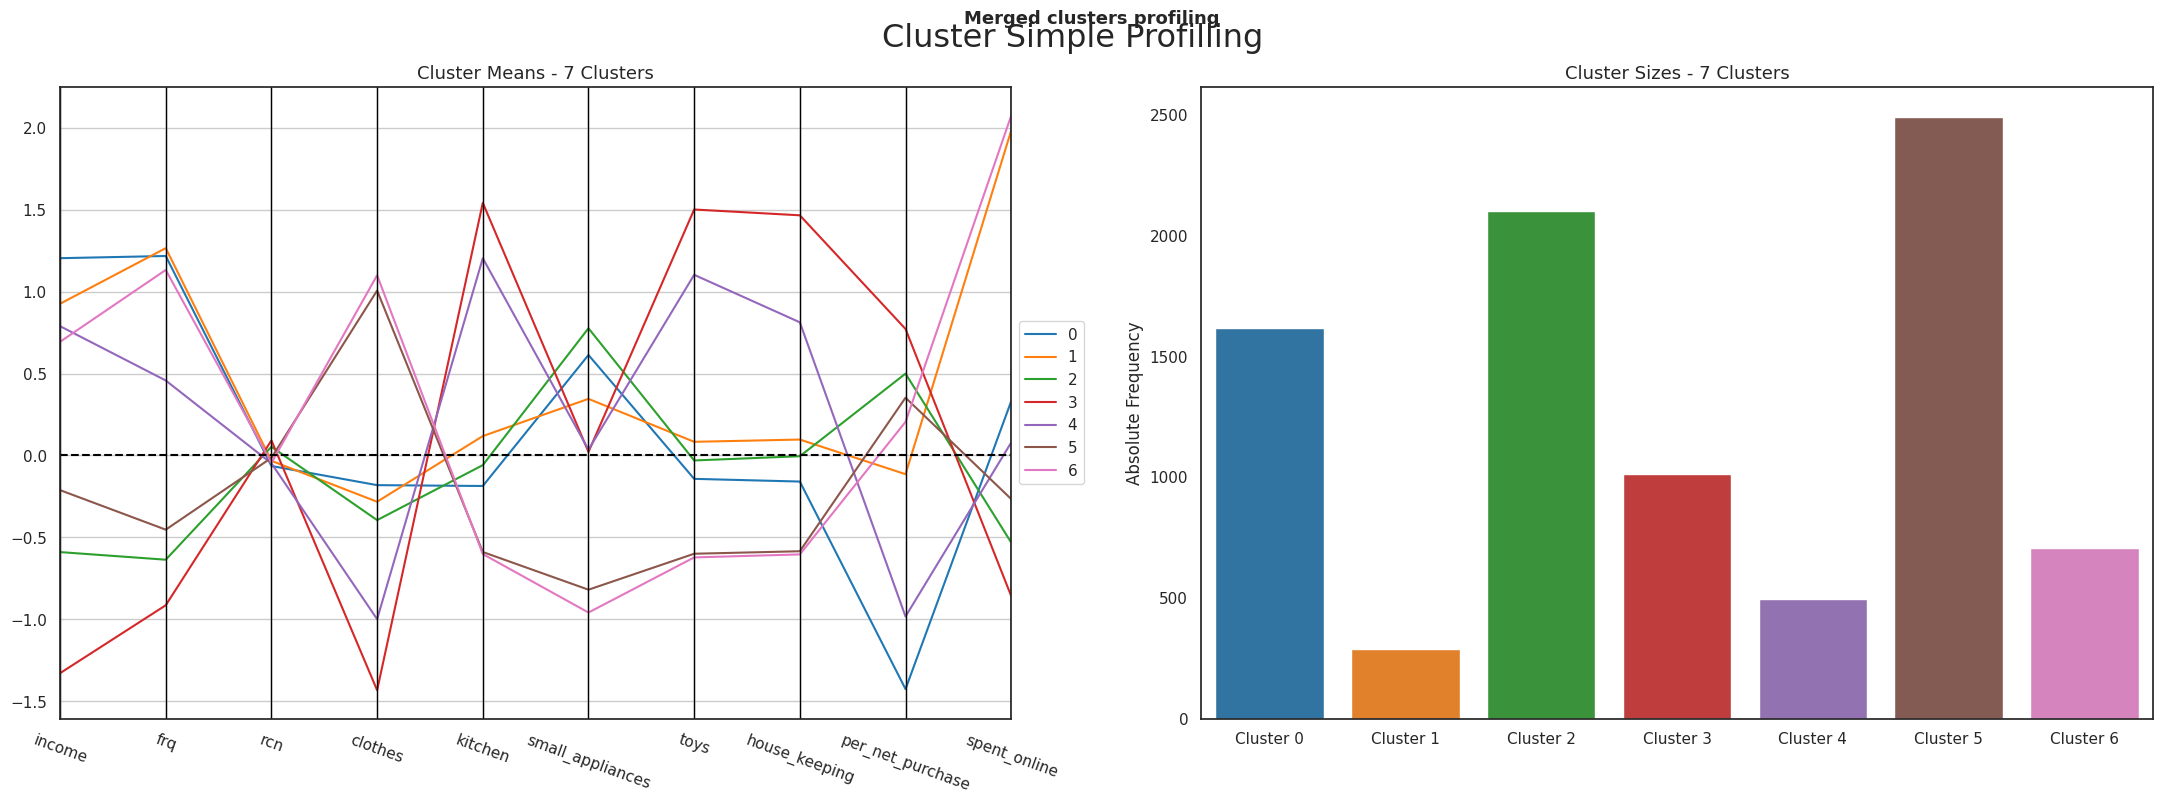

In [111]:
# Profilling each cluster (only merged)
merged_label_list = [merged_label_name]
sns.set(style="white")
cluster_profiles(
    df = df[metric_features + merged_label_list],
    label_columns = merged_label_list,
    figsize = (27, 8),
    compar_titles = ["Merged clusters profiling"],
    colors='tab10'
)


<ipython-input-108-a79530ec42ab>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<ipython-input-108-a79530ec42ab>:29: UserWarning: The palette list has more values (8) than needed (4), which may not be intended.
  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<ipython-input-108-a79530ec42ab>:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(cluster_labels)
<ipython-input-108-a79530ec42ab>:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label, y="counts", data=counts, ax=ax[1],
<ipython-input-108-a79530ec42ab>:29: UserWarning: 

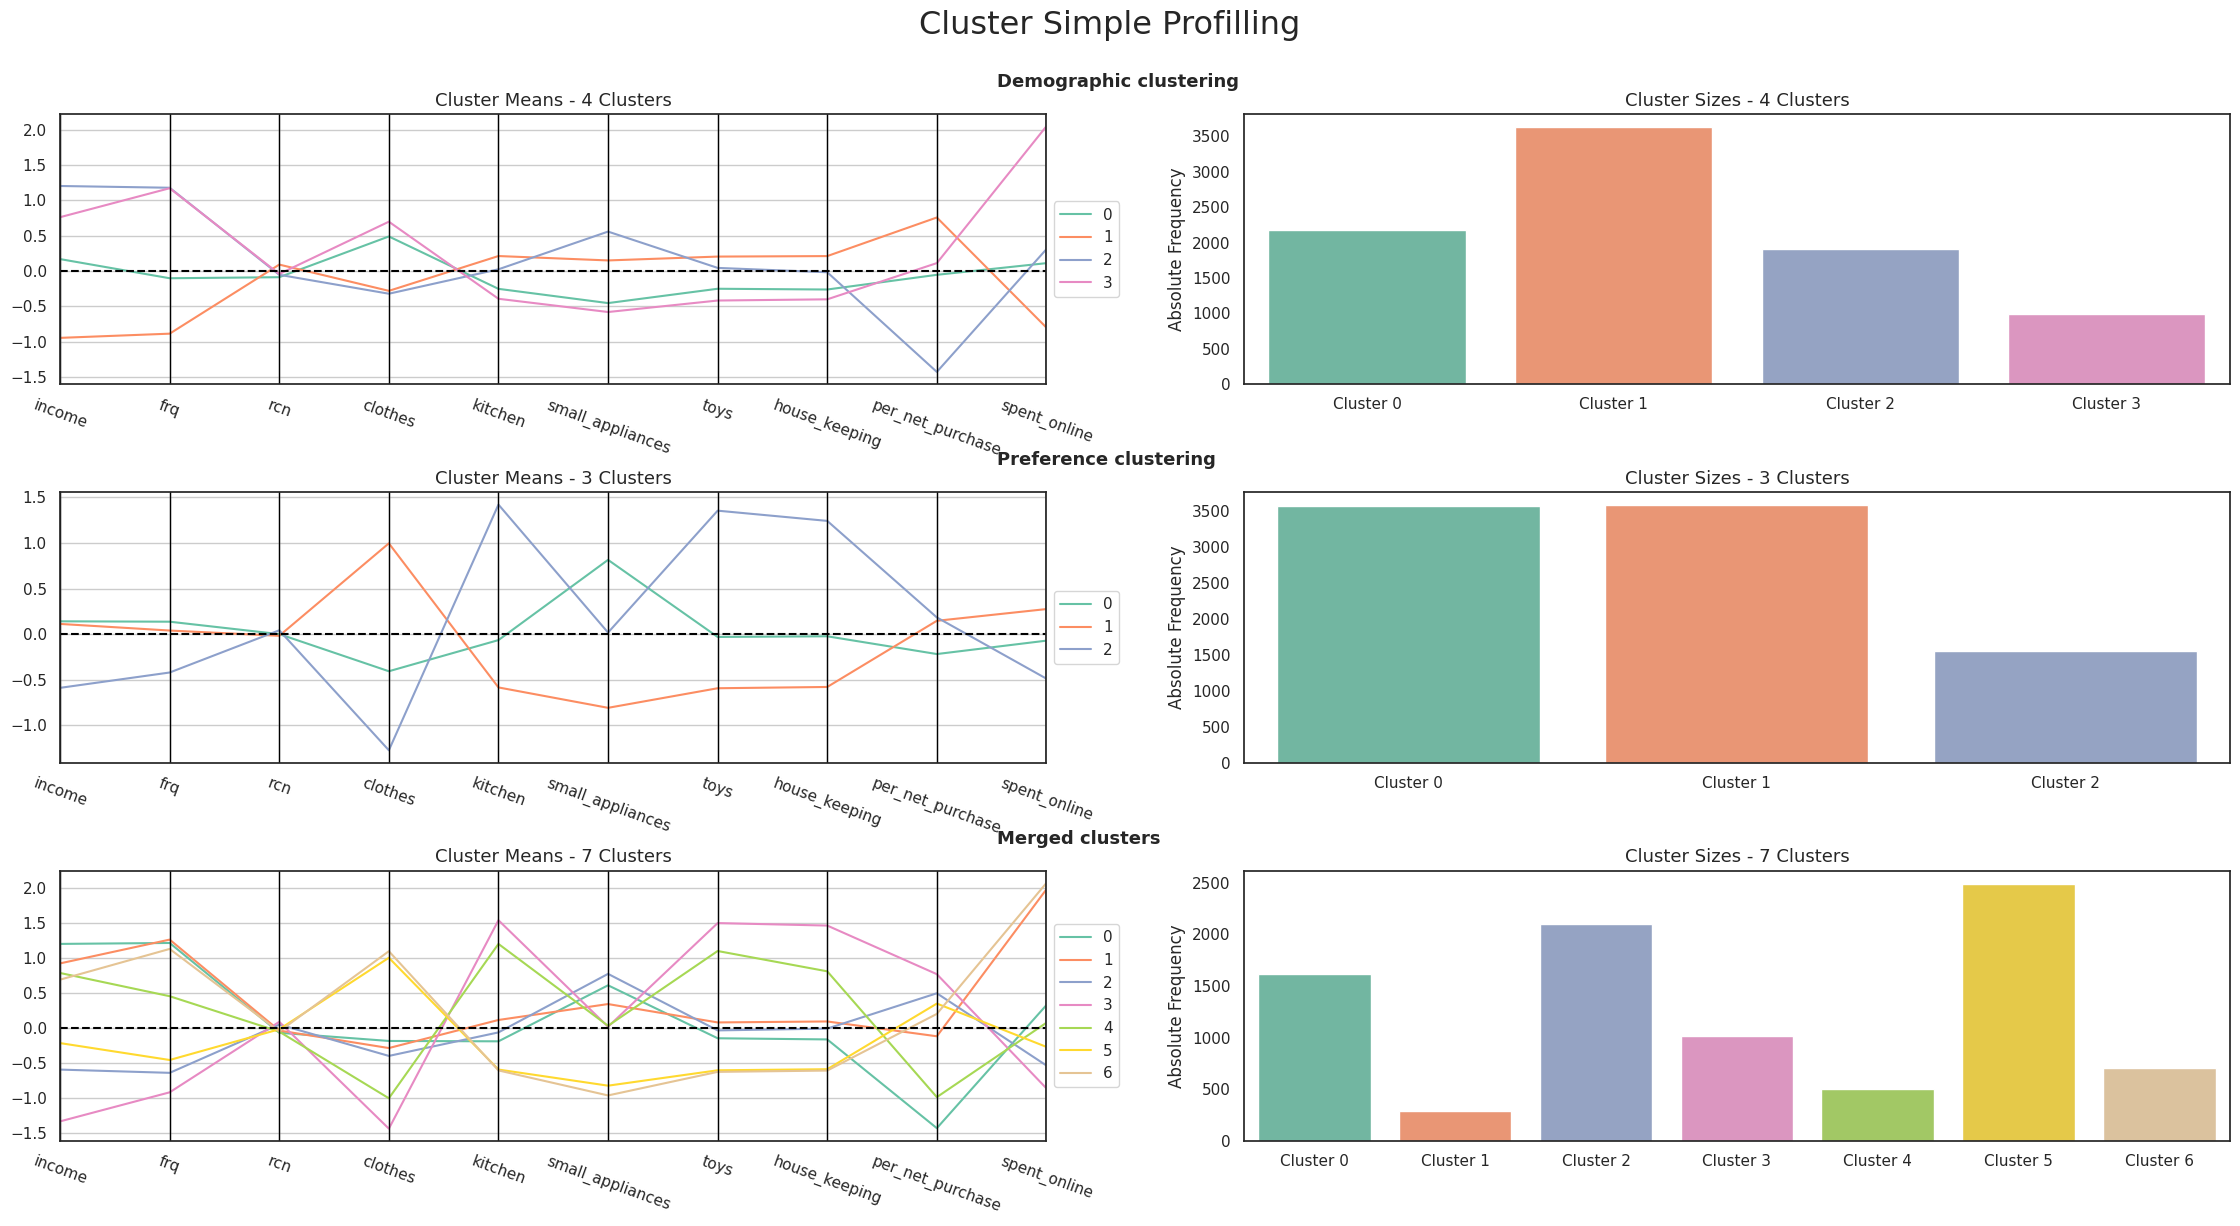

In [112]:
# Profilling each cluster (product, behavior, merged)
sns.set(style="white")
cluster_profiles(
    df = df[metric_features + labels_list],
    label_columns = labels_list,
    figsize = (28, 13),
    compar_titles = ["Demographic clustering", "Preference clustering", "Merged clusters"],
    colors='Set2'
)


## Visualize profiles using heatmaps

In [113]:
def cluster_heatmaps(df,
                     label_columns,
                     figsize=(20,20),
                     compar_titles=None,
                     heat_colors='RdYlBu',
                     bar_colors='Set2'):
    """
    Pass df with labels columns of one or multiple clustering labels.
    Then specify this label columns to perform the cluster profile according to them.
    """
    if compar_titles == None:
        compar_titles = [""]*len(label_columns)

    fig, axes = plt.subplots(nrows=len(label_columns), ncols=2,
                             figsize=figsize, squeeze=False)
    for ax, label, titl in zip(axes, label_columns, compar_titles):

        # Filtering df
        drop_cols = [i for i in label_columns if i!=label]
        dfax = df.drop(drop_cols, axis=1)

        # Getting the cluster centroids and counts
        centroids = dfax.groupby(by=label, as_index=False).mean()
        counts = dfax.groupby(by=label, as_index=False).count().iloc[:,[0,1]]
        counts.columns = [label, "counts"]


        # Setting Data
        handles, _ = ax[0].get_legend_handles_labels()
        cluster_labels = ["Cluster {}".format(i) for i in range(counts.shape[0])]

        sns.heatmap(centroids.drop(columns=label),
              square=False, cmap=heat_colors,
              ax=ax[0],
              )

        ax[0].set_title("Cluster Means Heatmap - {} Clusters".format(counts.shape[0]), fontsize=18)
        ax[0].set_xticklabels(ax[0].get_xticklabels(), rotation=-20)
        ax[0].set_yticklabels(cluster_labels, rotation=0)
        ax[1].annotate(text=titl, xy=(-0.3,1.15),
                       xycoords='axes fraction',
                       fontsize=18, fontweight = 'heavy')


        sns.barplot(y=label, x="counts", data=counts, ax=ax[1], orient='h', palette=bar_colors)
        ax[1].set_yticklabels(cluster_labels)
        ax[1].set_title("Cluster Sizes - {} Clusters".format(counts.shape[0]), fontsize=18)
        ax[1].set_ylabel("")

    plt.subplots_adjust(hspace=0.4, top=0.90)
    plt.suptitle("Cluster Simple Profilling", fontsize=23)
    plt.show()

<ipython-input-113-1dc75a3208d5>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=label, x="counts", data=counts, ax=ax[1], orient='h', palette=bar_colors)
<ipython-input-113-1dc75a3208d5>:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(cluster_labels)


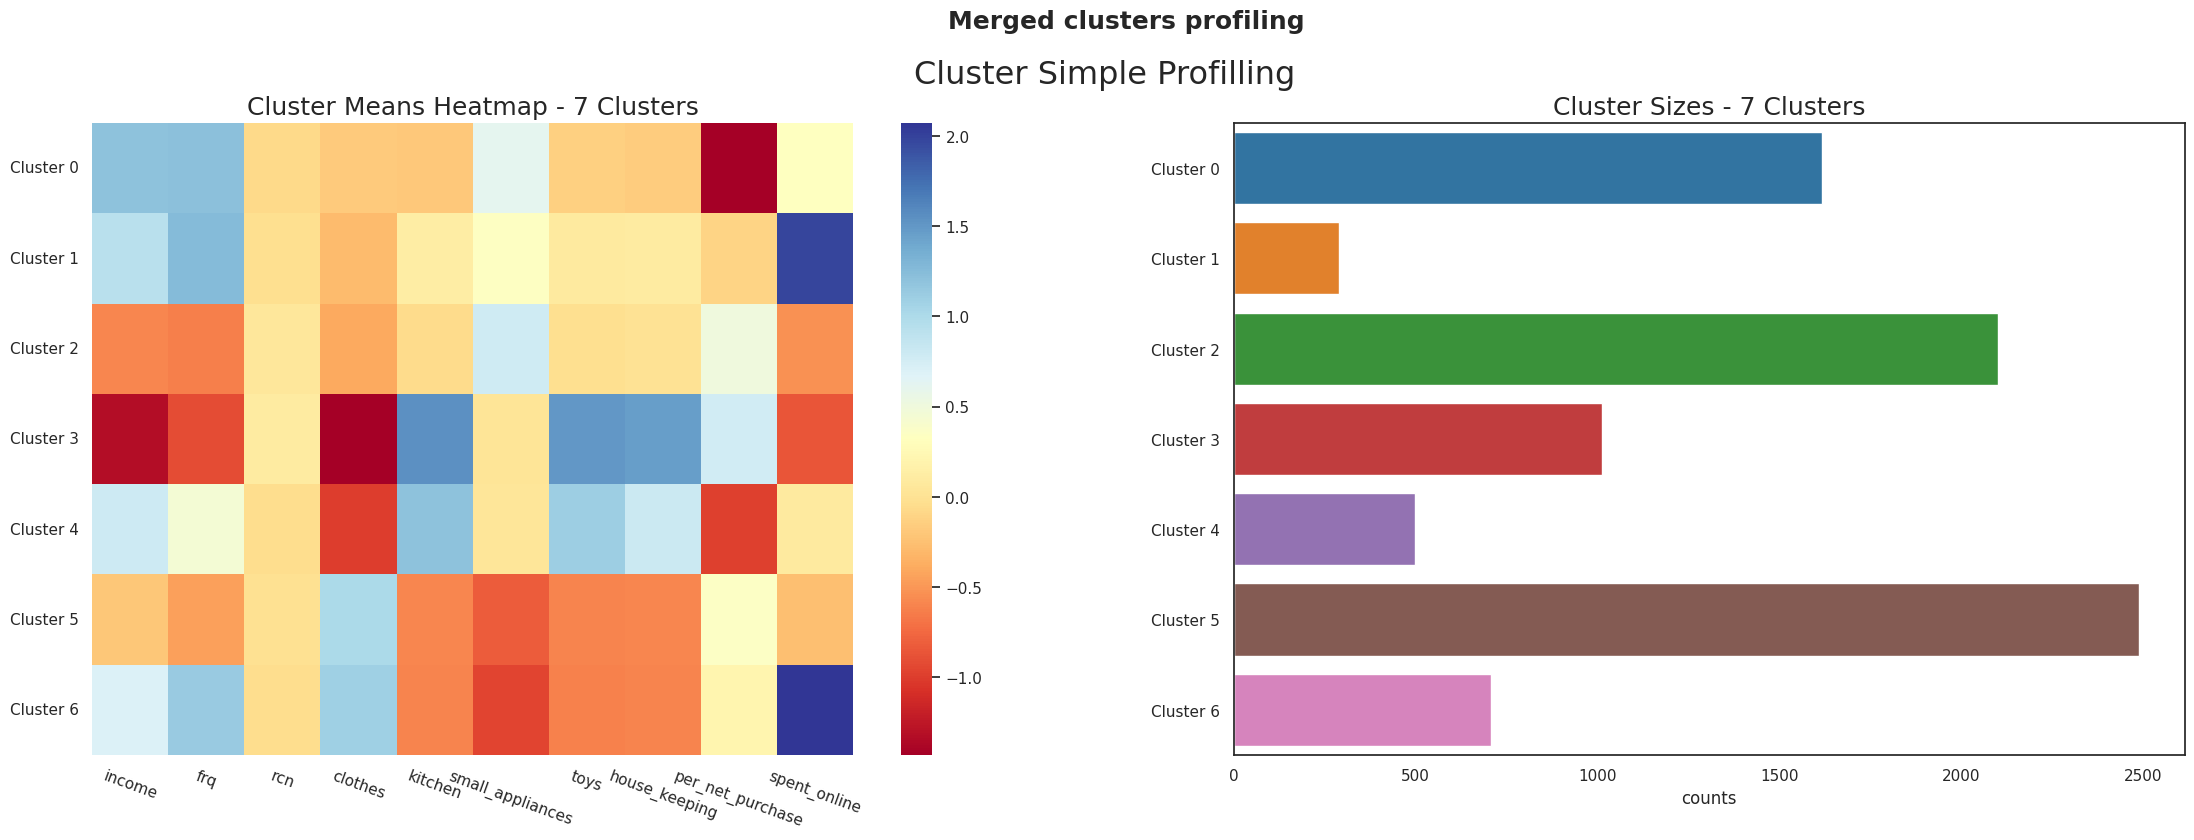

In [114]:

# Profilling each cluster (only merged)
merged_label_list = [merged_label_name]
sns.set(style="white")
cluster_heatmaps(
    df = df[metric_features + merged_label_list],
    label_columns = merged_label_list,
    figsize = (27, 8),
    compar_titles = ["Merged clusters profiling"],
    bar_colors='tab10'
)

sns.set()


<ipython-input-113-1dc75a3208d5>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=label, x="counts", data=counts, ax=ax[1], orient='h', palette=bar_colors)
<ipython-input-113-1dc75a3208d5>:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_yticklabels(cluster_labels)
<ipython-input-113-1dc75a3208d5>:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=label, x="counts", data=counts, ax=ax[1], orient='h', palette=bar_colors)
<ipython-input-113-1dc75a3208d5>:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].se

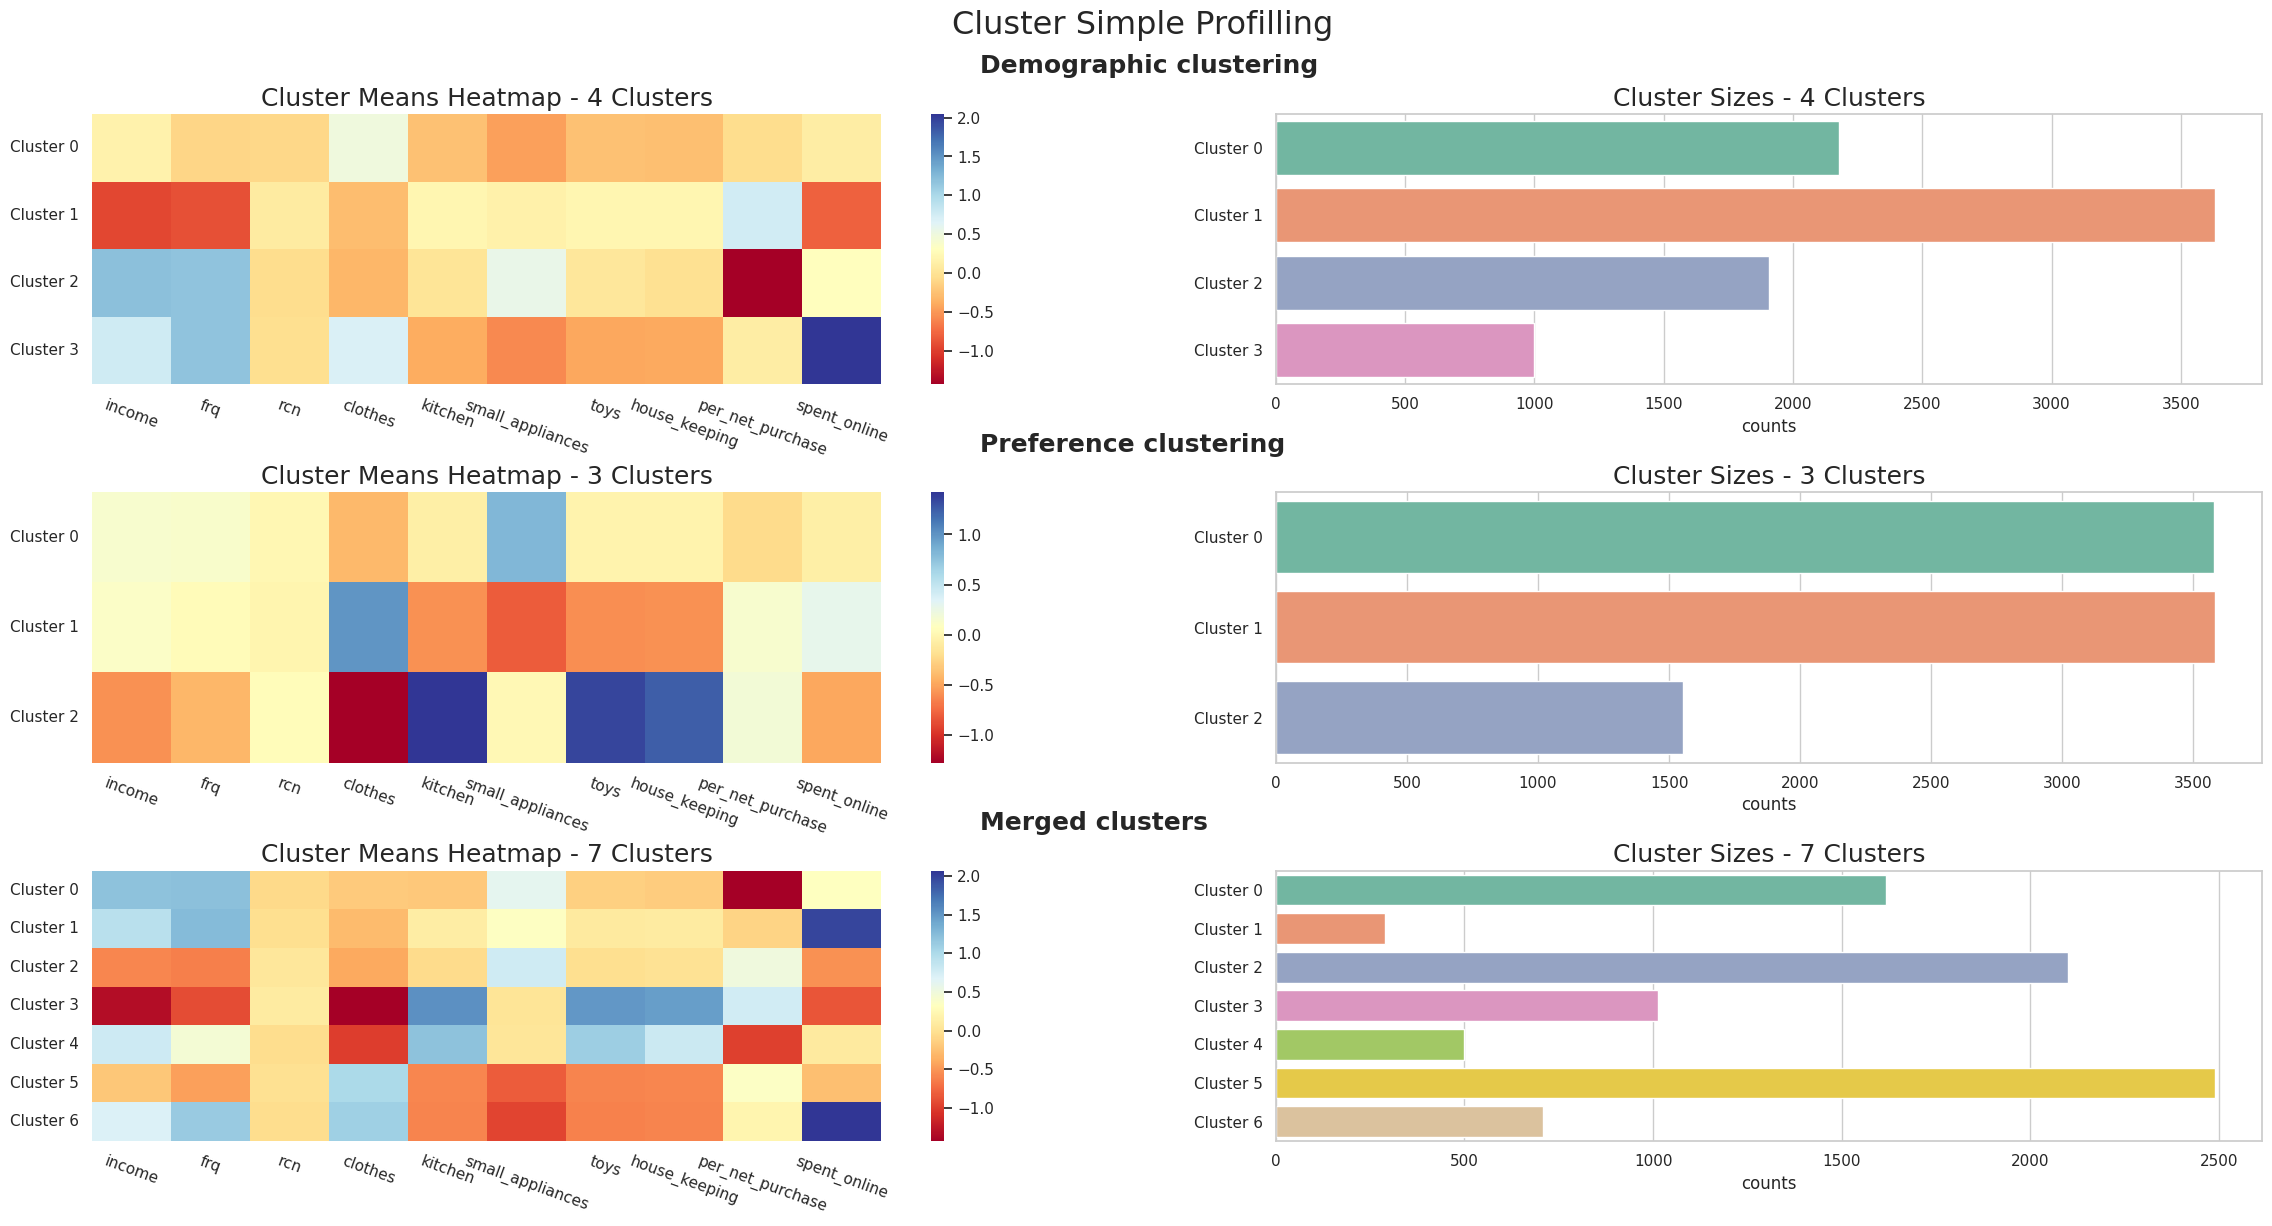

In [115]:
# Profilling each cluster (product, behavior, merged)
sns.set(style="whitegrid")
cluster_heatmaps(
    df = df[metric_features + labels_list],
    label_columns = labels_list,
    figsize = (28, 13),
    compar_titles = ["Demographic clustering", "Preference clustering", "Merged clusters"],
)


## Tabular cluster characterization

### Recover original values

Remember, we scaled our data during preprocessing

In [116]:
## Check the variable name of the scaler you chose to use

scaler

StandardScaler()

In [117]:
scaled_feature_names = scaler.get_feature_names_out()
scaled_feature_names


array(['income', 'frq', 'rcn', 'clothes', 'kitchen', 'small_appliances',
       'toys', 'house_keeping', 'per_net_purchase', 'spent_online'],
      dtype=object)

In [118]:
## Get the inverse of the transformed values
pd.DataFrame(scaler.inverse_transform(df[scaled_feature_names]),
             columns=scaled_feature_names)

,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,per_net_purchase,spent_online
0,90782.0,33.0,66.0,37.0,5.0,44.0,10.0,3.0,19.0,266.38
1,113023.0,32.0,6.0,55.0,1.0,38.0,4.0,2.0,9.0,138.33
2,28344.0,11.0,69.0,32.0,19.0,24.0,1.0,24.0,59.0,25.96
3,93571.0,26.0,10.0,60.0,10.0,19.0,6.0,5.0,35.0,310.80
4,91852.0,31.0,26.0,59.0,5.0,28.0,4.0,4.0,34.0,386.92
...,...,...,...,...,...,...,...,...,...,...
8710,87399.0,25.0,1.0,56.0,8.0,27.0,8.0,1.0,47.0,393.39
8711,94367.0,28.0,1.0,68.0,5.0,21.0,3.0,4.0,55.0,492.80
8712,58121.0,12.0,6.0,53.0,6.0,28.0,7.0,6.0,71.0,43.31
8713,54292.0,29.0,72.0,41.0,11.0,36.0,1.0,11.0,31.0,313.41


In [119]:
## Put this into a DF

df_unscaled = df.copy()

df_unscaled[scaled_feature_names] = pd.DataFrame(scaler.inverse_transform(df[scaled_feature_names]),
                           index=df.index)

df_unscaled.head()

,Unnamed: 0,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,dependents,...,gender_M,dependents_1.0,description_Kind of OK,description_Meh...,description_OK nice!,description_Take my money!!,dbscan_labels,pref_labels,demog_labels,hc_merged_labels
0,0,90782.0,33.0,66.0,37.0,5.0,44.0,10.0,3.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0,0,2,0
1,1,113023.0,32.0,6.0,55.0,1.0,38.0,4.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0,0,2,0
2,2,28344.0,11.0,69.0,32.0,19.0,24.0,1.0,24.0,1.0,...,1.0,1.0,1.0,0.0,0.0,0.0,0,2,1,3
3,3,93571.0,26.0,10.0,60.0,10.0,19.0,6.0,5.0,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0,1,0,5
4,4,91852.0,31.0,26.0,59.0,5.0,28.0,4.0,4.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0,1,3,6


In [120]:
cluster_means = get_mean_bylabel(df_unscaled,
                                 metric_features,
                                 merged_label_name)

cluster_means.style.format(precision=2).background_gradient(axis=0)

,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,per_net_purchase,spent_online
hc_merged_labels,,,,,,,,,,
0,103326.58,33.28,50.29,47.02,5.42,36.39,5.60,5.56,15.90,234.16
1,95752.46,33.80,51.24,44.69,7.64,33.02,7.16,7.50,40.13,512.55
2,54473.74,13.05,53.82,42.11,6.35,38.45,6.37,6.73,51.47,88.83
3,34346.49,10.01,54.99,18.27,18.04,28.94,16.93,17.81,56.51,33.83
4,92024.65,24.98,50.78,28.22,15.57,29.12,14.18,12.89,24.08,191.67
5,64771.17,15.05,51.79,74.30,2.47,18.36,2.45,2.36,48.76,133.57
6,89429.19,32.35,50.86,76.45,2.38,16.60,2.29,2.21,46.03,527.84


In [121]:
## Do the same with pref_labels and demog_labels instead of merged_labels


In [122]:
cluster_means_1 = get_mean_bylabel(df_unscaled,
                                 metric_features,
                                 perspective_1)
cluster_means_1
# cluster_means_1.style.format(precision=2).background_gradient(axis=0)

,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,per_net_purchase,spent_online
pref_labels,,,,,,,,,,
0,74359.838737,21.477641,52.224427,41.825321,6.297652,38.926775,6.366685,6.584964,38.204025,166.313376
1,73580.231929,20.419481,51.662573,74.057215,2.504326,18.496790,2.490371,2.396316,44.940553,224.674694
2,54486.867439,15.396396,53.484556,21.911840,17.158301,28.888031,15.912484,16.123552,45.624196,96.034003


In [123]:
cluster_means_2 = get_mean_bylabel(df_unscaled,
                                 metric_features,
                                 perspective_2)

cluster_means_2.round(2)
# cluster_means_2.style.format(precision=2).background_gradient(axis=0)


,income,frq,rcn,clothes,kitchen,small_appliances,toys,house_keeping,per_net_purchase,spent_online
demog_labels,,,,,,,,,,
0,75136.83,18.88,49.60,62.41,4.94,22.97,4.85,4.80,41.25,197.19
1,44801.70,10.33,54.97,44.74,8.33,30.56,7.99,8.36,56.23,43.61
2,103284.13,32.84,50.63,43.81,6.96,35.70,6.89,6.64,15.89,230.50
3,91268.45,32.77,50.97,67.21,3.91,21.38,3.71,3.75,44.31,523.40


### Non-metric features profiling

In [124]:
## Characteristics considering merged labels segmentation (non metric)
## MODE of each feature for each cluster

df.groupby([merged_label_name])[non_metric_features].agg(pd.Series.mode)

,education,status,gender,dependents,description
hc_merged_labels,,,,,
0,Graduation,Married,M,0.0,OK nice!
1,Graduation,Married,M,1.0,OK nice!
2,Graduation,Married,M,1.0,OK nice!
3,1st Cycle,Single,M,1.0,Meh...
4,2nd Cycle,Married,M,0.0,OK nice!
5,Graduation,Married,M,1.0,OK nice!
6,Graduation,Married,M,1.0,OK nice!


In [125]:
def categorical_profiling(df,
                          feats,
                          label,
                          figsize=(12,10),
                          title=None,
                          bar_colors='Set2'):

  labels_list = np.sort(df[label].unique()).tolist()

  fig, axes = plt.subplots(len(feats), len(labels_list),
                        figsize=figsize,
                        sharex='row',
                        sharey='row',
                        tight_layout=True)

  for li in labels_list:
    row_df = df[df[label]==li]

    for ci, cat in enumerate(feats):
      ax = axes[ci][li]
      sns.countplot(ax=ax, y=row_df[cat], orientation='horizontal', palette=bar_colors)

      ax.set_xlabel("")

      if ci==0:
        ax.set_title("Cluster {}".format(li))
      else:
        ax.set_title("")

      if li==0:
        ax.set_ylabel(cat)
      else:
        ax.set_ylabel("")

  fig.suptitle(title, y=1.01)
  plt.show()



<ipython-input-125-6c5a25cb6934>:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=ax, y=row_df[cat], orientation='horizontal', palette=bar_colors)


ConversionError: Failed to convert value(s) to axis units: None

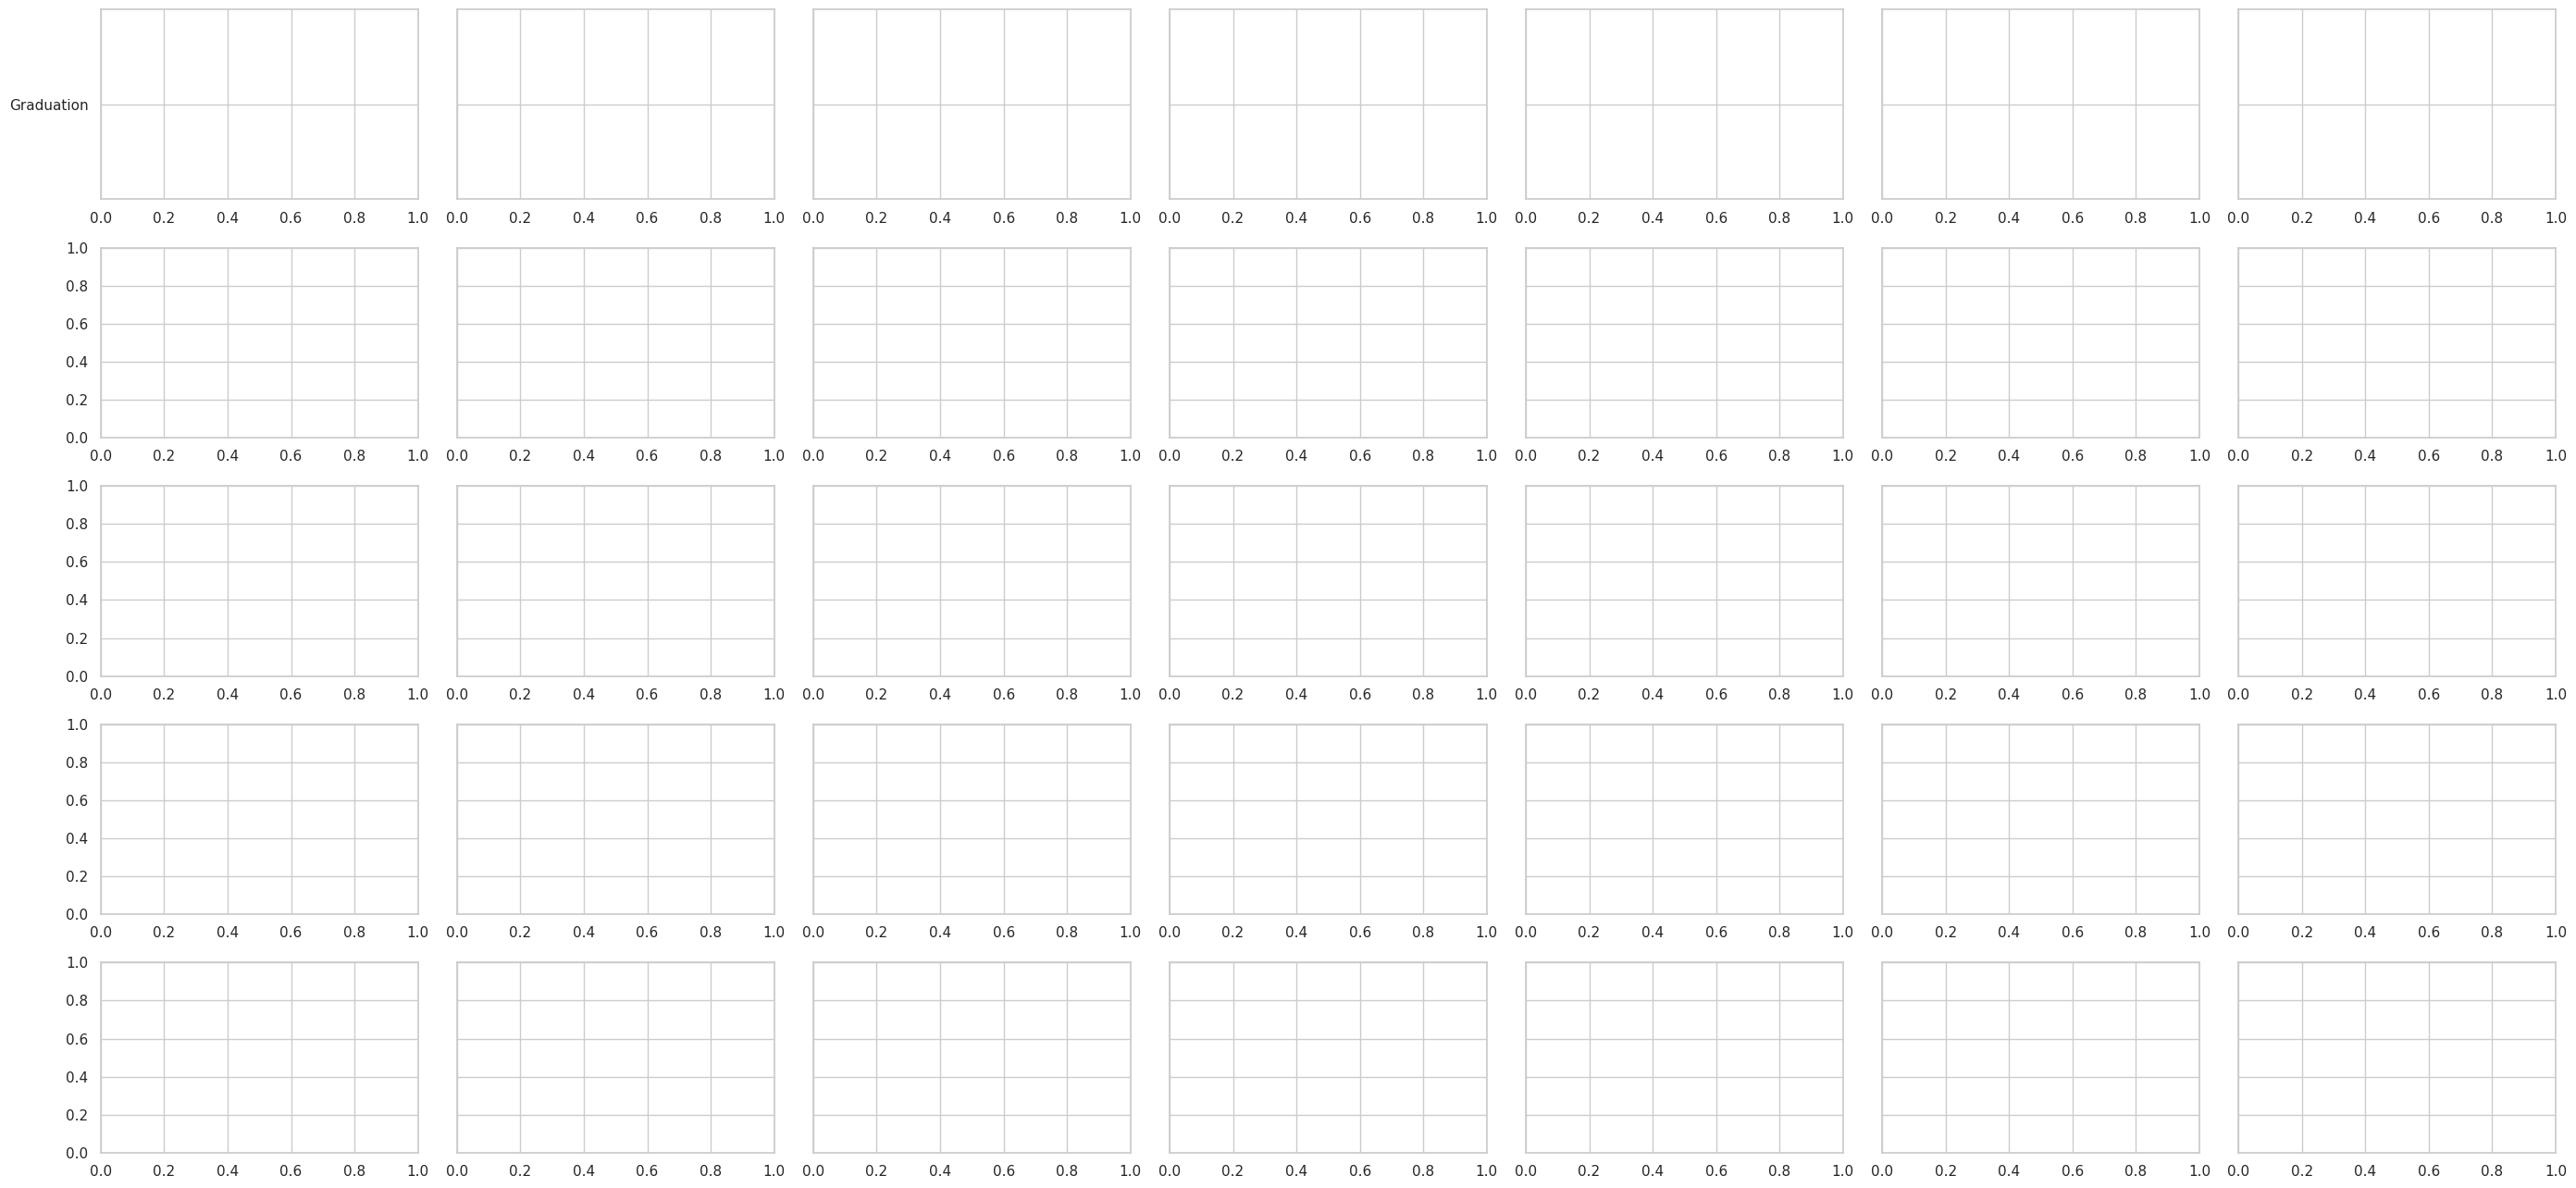

In [126]:
# Profilling each cluster (merged)
sns.set(style="whitegrid")
categorical_profiling(
    df = df[non_metric_features + labels_list],
    feats = non_metric_features,
    label = merged_label_name,
    figsize = (28, 13),
    title = "Merged Clustering"
)


In [ ]:
# Profilling each cluster (pref)
sns.set(style="whitegrid")
categorical_profiling(
    df = df[non_metric_features + labels_list],
    feats = non_metric_features,
    label = perspective_1,
    figsize = (28, 13),
    title = "Preference Clustering"
)


## Cluster Visualization using TSNE

In [127]:
df.columns

Index(['Unnamed: 0', 'income', 'frq', 'rcn', 'clothes', 'kitchen',
       'small_appliances', 'toys', 'house_keeping', 'dependents',
       'per_net_purchase', 'gender', 'education', 'status', 'description',
       'spent_online', 'education_2nd Cycle', 'education_Graduation',
       'education_Master', 'education_PhD', 'status_Married', 'status_Single',
       'status_Together', 'status_Widow', 'gender_M', 'dependents_1.0',
       'description_Kind of OK', 'description_Meh...', 'description_OK nice!',
       'description_Take my money!!', 'dbscan_labels', 'pref_labels',
       'demog_labels', 'hc_merged_labels'],
      dtype='object')

In [128]:
def plot_tsne(df, feats, label,
              cmap='tab10',
              title="t-SNE Visualization of Clustering Solution"):

  two_dim = TSNE(random_state=42).fit_transform(df[feats])
  two_dim_df = pd.DataFrame(two_dim, index=df.index)
  two_dim_df[label] = df[label]


  fig, ax= plt.subplots(figsize=(10,10))
  scatter = ax.scatter(x = two_dim_df[0],
                      y=two_dim_df[1],
                      c=two_dim_df[label],
                      s=5,
                      cmap=cmap
                      )
  ax.set_xlabel("")
  ax.set_ylabel("")
  ax.set_xticks([])
  ax.set_yticks([])

  legend1 = ax.legend(*scatter.legend_elements(),
                      loc="best", title="Cluster Labels")
  ax.add_artist(legend1)

  plt.title(title)
  plt.show()

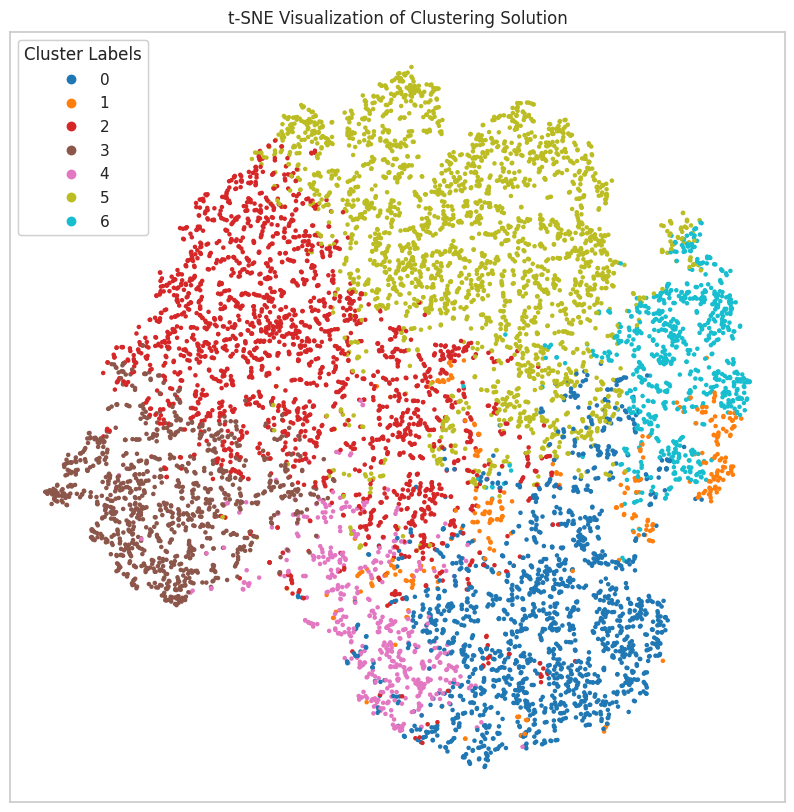

In [129]:
plot_tsne(df, metric_features, merged_label_name)

## Feature importance and reclassifying noise / outliers

### Decision Tree

In [ ]:
# Preparing the data
X = df[metric_features]
y = df[merged_label_name]

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Fitting the decision tree
dt = DecisionTreeClassifier(random_state=42, max_depth=4)
dt.fit(X_train, y_train)
print("It is estimated that on average, we are able to predict {0:.2f}% of the customers correctly".format(dt.score(X_test, y_test)*100))



In [ ]:
# Assessing feature importance
pd.Series(dt.feature_importances_, index=X_train.columns).sort_values(ascending=False)


In [ ]:
## Remember our noise rows that we removed with DBSCAN?
## Predicting the cluster labels of the outliers

df_noise[merged_label_name] = dt.predict(df_noise[metric_features])
df_noise[metric_features + [merged_label_name]].head()

In [ ]:
# Visualizing the decision tree
num_of_clusters = len(df[merged_label_name].unique())
cluster_names = ["Cluster {}".format(i) for i in range(num_of_clusters)]
dot_data = export_graphviz(dt, out_file=None,
                           feature_names=X.columns.to_list(),
                           filled=True,
                           rounded=True,
                           class_names=cluster_names,
                           special_characters=True)


In [ ]:
### optionally save dt png
import pydotplus
graph = pydotplus.graph_from_dot_data(dot_data)
graph.write_png('cluster_decision_tree.png')

## Open sidebar to download the image

## END of Practical Sessions

### Questions?

### How is your project?